In [1]:
#################### DOCUMENTATION #########################
'''
Author: Spencer Ressel
Date: 2025-10-27

This code runs the NeuralGCM model using ERA5 data as an initial condition. It is designed to run the model in a quasi-linear way, with a mean-state term that does not evolve in time and a small MJO perturbation that evolves relative to the mean-state. In this version, the mean-state correction is applied to the decoded state values. 


'''
""

######################### IMPORTS ##########################

print(f"{'Loading imports...':<30}", end="")
# JAX & NeuralGCM
import gcsfs
import jax
from jax import config
import jax.numpy as jnp
from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm
from neuralgcm import PressureLevelModel

# IO Functions
import copy
import pickle
import json
import os
import sys
from pathlib import Path
# base_directory = Path("/u/sressel/neuralgcm/model_outputs")
base_directory = Path("/glade/u/home/sressel/thesis-work/python/neuralGCM_analysis/")

# Scientific analysis functions
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime

# Auxiliary Functions
from jax_helper_functions import *
from smooth_encoded_state import smooth_encoded_state
# from spherical_to_nodal import spherical_to_nodal
print('\u2713')
""
#correction_interval = int(sys.argv[1])

#################### SIMULATION PARAMETERS ####################
experiment_name = f'decoded_correction_test_4_1'
experiment_description = f'This is a 1-day test of the 2.8deg deterministic model with 1-hr timesteps. The correction is applied to the decoded states. This run should result in outputs that do not change in time. I haven\'t changed anything, I just want to see the behavior.'
simulation_parameters = dict(
    add_perturbation = False,
    correct_mean_state = True,
    smooth_initial_conditions = False
)
output_parameters = dict(
    save_encoded_model_state = False,
    save_encoded_mean_state_correction = False,
    save_decoded_mean_state_correction = False
)
#### Specify the number of timesteps
n_timesteps = int(10*24)

# Specify the wavenumber beyond which to smooth
truncation_wavenumber = 40

# How often the correction should be applied in hours
correction_interval = None

# JAX random key (only used for stochastic models)
random_key = 37
rng_key = jax.random.key(random_key)

print(f"{'Specifying model...':<30}", end="")
# model_name = '../neuralgcm/neuralgcm/checkpoints/deterministic_2_8_deg.pkl'
# # model_name = '../neuralgcm/neuralgcm/checkpoints/models_v1_precip_stochastic_precip_2_8_deg.pkl'
# with open(f"{model_name}", "rb") as f:
#     ckpt = pickle.load(f)

# model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
model_name = 'v1/deterministic_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}
# model_name = 'v1_precip/stochastic_precip_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
  ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print('\u2713')
""

################### LOAD INITIAL CONDITIONS ###################
print(f"{'Loading initial conditions...':<30}", end="")
demo_start_time = '2000-01-15'
# eval_era5 = xr.load_dataset(
#     f"../neuralgcm/neuralgcm/input/2_8_thirty_year_DJF_climatology.nc"
# ).isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')])
eval_era5 = xr.load_dataset(
    f"./2_8_thirty_year_DJF_climatology.nc"
).drop_vars('time_bnds').isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')])
print('\u2713')

#### Add a perturbation
# mjo_composites = xr.load_dataset(
#     f"../neuralgcm/neuralgcm/input/MJO_phase_composites.nc"
# )

print(f"{'Configuring model...':<30}", end="")
# initialize model state (bring ERA5 snapshot --> encoding into the model's latent state)
inputs_dict = model.inputs_from_xarray(eval_era5.isel(time=0))
inputs_array = model.data_to_xarray(inputs_dict, times=None)
# perturbed_inputs_dict = model.inputs_from_xarray((eval_era5 + mjo_composites.sel(phase=5, drop=True)).isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))

# Encode initial data into model state
encoded_mean_state = model.encode(inputs_dict, input_forcings, rng_key)
# encoded_perturbed_initial_state = model.encode(perturbed_inputs_dict, input_forcings, rng_key)

if simulation_parameters['smooth_initial_conditions']:
    encoded_mean_state = smooth_encoded_state(encoded_mean_state)
    encoded_perturbed_initial_state = smooth_encoded_state(encoded_perturbed_initial_state)

# Create an initial condition based on whether a perturbation is included
if simulation_parameters['add_perturbation']:
    encoded_initial_state = copy.deepcopy(encoded_perturbed_initial_state)
else:
    encoded_initial_state = copy.deepcopy(encoded_mean_state)
print('\u2713')
""
################## CALCULATE MEAN-STATE CORRECTION ##############
print(f"{'Calculating mean-state correction...':<30}", end="")
# encoded_evolved_mean_state = copy.deepcopy(encoded_mean_state)
# encoded_evolved_mean_state.state = model.advance(encoded_mean_state, input_forcings).state
encoded_evolved_mean_state = model.advance(encoded_mean_state, input_forcings)
evolved_mean_state = model.data_to_xarray(model.decode(encoded_evolved_mean_state, input_forcings), times=None)

[inputs_array, evolved_mean_state] = xr.align(*[inputs_array, evolved_mean_state], join='override')

config.update("jax_enable_x64", True)
mean_state_correction = evolved_mean_state.astype(jnp.float64) - inputs_array.astype(jnp.float64)
config.update("jax_enable_x64", False)
print('\u2713')
""
######################### TIMESTEPPING ##########################
print(f"{'Running model...':<30}", end="")
advanced_states_list = []
advanced_states_list.append(inputs_array)

for timestep in np.arange(0, n_timesteps, 1):

    # Advance the model state forward by one timestep
    if timestep == 0:
        config.update("jax_enable_x64", False)
        encoded_advanced_state = model.advance(encoded_initial_state, input_forcings)
      
    else:
        config.update("jax_enable_x64", False)
        corrected_inputs = model.inputs_from_xarray(
            corrected_advanced_state.expand_dims(time=[pd.Timestamp('2000-01-15')]).isel(time=0)
        )
        encoded_corrected_model_state = model.encode(corrected_inputs, input_forcings, rng_key)
        encoded_advanced_state = model.advance(encoded_corrected_model_state, input_forcings)


    advanced_state = model.data_to_xarray(model.decode(encoded_advanced_state, input_forcings), times=None)
    # Align output to initial state
    [_, advanced_state] = xr.align(*[inputs_array, advanced_state], join='override')

    # Correct mean-state
    if simulation_parameters['correct_mean_state']:
        config.update("jax_enable_x64", True)
        corrected_advanced_state = (advanced_state.astype(jnp.float64) - mean_state_correction).astype(jnp.float32)
        config.update("jax_enable_x64", False)

    else:
        corrected_advanced_state = copy.deepcopy(advanced_state)

    advanced_states_list.append(corrected_advanced_state)
    
# Concatenate the states into a single DataArray
advanced_states_dataset = xr.concat(
    [state for state in advanced_states_list],
    dim=xr.DataArray(data=np.arange(len(advanced_states_list)), dims='time', coords=dict(time=np.arange(len(advanced_states_list))))
)
print('\u2713')
""
############################## OUTPUT ###########################
# print(f"{'Saving output...':<30}", end="")
# # Log model/experiment parameters
# experiment_parameters = {
#     'experiment_name': experiment_name,
#     'description': experiment_description,
#     'model_name': model_name,
#     'demo_start_time': demo_start_time,
#     'n_timesteps': n_timesteps,
#     'correction_interval': (correction_interval if simulation_parameters['correct_mean_state'] else None),
#     'random_key': random_key,
#     'simulation_parameters': simulation_parameters,
# }

# # Create a unique identifier for each experimental run
# file_timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# # Save each experiments data to a new folder
# output_folder_name = f"{experiment_parameters['experiment_name']}_{file_timestamp}"
# output_folder = base_directory / output_folder_name
# output_folder.mkdir(parents=True, exist_ok=False)

# # Save the experiment parameters
# json_path = output_folder / "experiment_parameters.json"
# with open(json_path, "w") as f:
#     json.dump(experiment_parameters, f, indent=4)

# # Save the experiment data
# advanced_states_dataset.to_netcdf(output_folder / "model_output.nc")

# if output_parameters['save_encoded_model_state']:
#     concatenated_encoded_states_ds.to_netcdf(output_folder / "model_output_encoded.nc")

# if output_parameters['save_encoded_mean_state_correction']:
#     encoded_mean_state_correction.to_netcdf(output_folder / "mean_state_correction_encoded.nc")
    
# if output_parameters['save_decoded_mean_state_correction']:
#     decoded_mean_state_correction.to_netcdf(output_folder / "mean_state_correction.nc")

# # Create running experiment log
# experiments_log_file = base_directory / "experiment_log.json"
# if experiments_log_file.exists():
#     with open(experiments_log_file, "r") as f:
#         log_data = json.load(f)

# else:
#     log_data = []

# log_data.insert(
#     0,
#     {
#         'experiment_name': experiment_parameters['experiment_name'],
#         'timestamp': file_timestamp,
#         'description': experiment_parameters['description']
#     }
# )

# # Save updated log
# with open(experiments_log_file, "w") as f:
#     json.dump(log_data, f, indent=4)

# # Path to the running script
# script_path = os.path.abspath(__file__)

# # Read the source code
# with open(script_path, 'r') as f:
#     script_contents = f.read()

# filename = f"decoded_correction_test_{file_timestamp}.py"

# # Save in the experiment folder
# save_path = os.path.join(output_folder, filename)
# with open(save_path, 'w') as f:
#     f.write(script_contents)
# print('\u2713')
""
print("Finished")


Loading imports...            ✓
Specifying model...           ✓
Loading initial conditions... ✓
Configuring model...          ✓
Calculating mean-state correction...✓
Running model...              ✓
Finished


In [3]:
[print(t.values, np.max(np.abs(advanced_states_dataset.sel(time=t) - advanced_states_dataset.sel(time=0)))) for t in advanced_states_dataset.time]

0 <xarray.Dataset> Size: 72B
Dimensions:                              ()
Coordinates:
    time                                 int64 8B 0
Data variables:
    v_component_of_wind                  float64 8B 0.0
    u_component_of_wind                  float64 8B 0.0
    temperature                          float64 8B 0.0
    sim_time                             float64 8B 0.0
    specific_humidity                    float64 8B 0.0
    specific_cloud_ice_water_content     float64 8B 0.0
    specific_cloud_liquid_water_content  float64 8B 0.0
    geopotential                         float64 8B 0.0
1 <xarray.Dataset> Size: 64B
Dimensions:                              ()
Data variables:
    v_component_of_wind                  float64 8B 0.0
    u_component_of_wind                  float64 8B 0.0
    temperature                          float64 8B 0.0
    sim_time                             float64 8B 0.0
    specific_humidity                    float64 8B 0.0
    specific_cloud_ice_water_

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

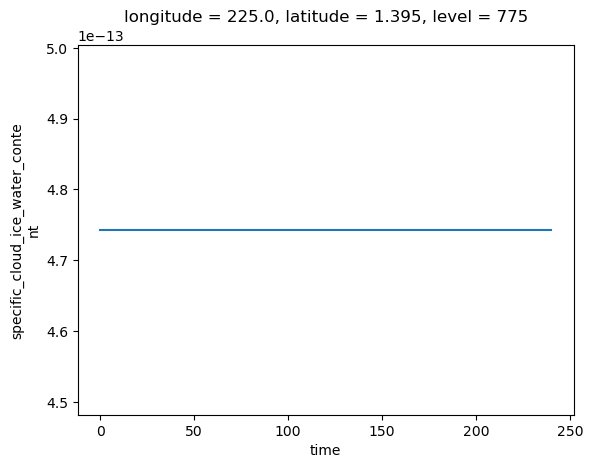

In [18]:
advanced_states_dataset['specific_cloud_ice_water_content'][:,-10,80,32].plot()